<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/Redes_Neurais_tarefa1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neurais Artificiais e Deep Learning — Atividade 1

**Aluno:** Viktor Uebelhart  RA: 100462

**Curso:** Pós-graduação em Ciências de Dados — Centro Universitário Facens

**Disciplina:** Redes Neurais Artificiais e Deep Learning

**Data:** setembro de 2026

# Exemplo 1 — Funcionamento básico do Perceptron

**Objetivo do exemplo:** Demonstrar, sem nenhum treinamento, como um Perceptron
transforma um conjunto de entradas em uma única saída binária. O foco é observar o
caminho `entradas → multiplicação pelos pesos → soma ponderada → bias → função de
ativação → saída`, com todos os parâmetros definidos manualmente pelo programador.

**Problema analisado:** Não há aqui um problema de negócio real. O problema é
didático: dado um vetor de entrada e um conjunto de parâmetros já conhecidos,
determinar qual classe (0 ou 1) o neurônio artificial atribui a essa entrada.
É a etapa de **inferência** do Perceptron, isolada da etapa de aprendizagem.

**Modelo/Técnica:** Perceptron simples, um único neurônio
artificial com função de ativação degrau (*step function*), implementado
manualmente em Python/NumPy, sem uso de bibliotecas de machine learning.

**Entradas:** Um vetor com 2 atributos numéricos, `x = [0.2, 0.3]`, acompanhado dos
parâmetros do neurônio definidos previamente: os pesos sinápticos `w = [0.5, 0.5]`
e o bias `b = 0.0`.

**Saída esperada:** Um único valor binário (0 ou 1), resultado da aplicação da
função degrau sobre a soma ponderada. Para os parâmetros acima, espera-se saída 1.

**Dataset utilizado:** Nenhum dataset externo. O exemplo utiliza dados definidos
diretamente no código (entradas, pesos e bias fixados manualmente), portanto não
se aplica a seção "Análise do Dataset".

In [37]:
import numpy as np

# Função de ativação - Função degrau
def step_function(x):
    return 1 if x > 0 else 0


# Perceptron (neurônio artificial)
def perceptron(input_data, weights):
    # Calcula a soma ponderada das entradas e pesos
    weighted_sum = np.dot(input_data, weights)

    # Aplica a função de ativação
    output = step_function(weighted_sum)

    return output


# Pesos sinápticos (pesos do perceptron)
weights = np.array([0.5, 0.5])  # Inicialização aleatória


# Dados de entrada
input_data = np.array([0.2, 0.3])


# Calcula a saída do perceptron
output = perceptron(input_data, weights)


# Exibe a saída
print("Saída do perceptron:", output)

Saída do perceptron: 1


## Análise do Exemplo 1

### 1. Qual é a função dos pesos associados às entradas do Perceptron?

Os pesos definem a **importância de cada entrada** na decisão do neurônio. Cada
entrada é multiplicada pelo seu peso antes de entrar na soma ponderada:

z = (x1 · w1) + (x2 · w2)

Assim:
- peso alto → a entrada tem forte influência no resultado;
- peso próximo de zero → a entrada é praticamente ignorada;
- peso negativo → a entrada passa a atuar contra a ativação.

No experimento, com `w = [0.5, 0.5]` e `x = [0.2, 0.3]`, as contribuições foram
0.10 e 0.15. Como os pesos são iguais, nenhuma entrada foi privilegiada.

### 2. Qual é a função do bias e o que pode acontecer com a saída caso seu valor seja alterado?

In [38]:
import numpy as np

# Função de ativação - Função degrau
def step_function(x):
    return 1 if x > 0 else 0


# Perceptron com bias
def perceptron(input_data, weights, bias):
    weighted_sum = np.dot(input_data, weights) + bias
    output = step_function(weighted_sum)
    return weighted_sum, output


weights = np.array([0.5, 0.5])
input_data = np.array([0.2, 0.3])

# Bias original
z, output = perceptron(input_data, weights, 0.0)
print("bias =  0.0  ->  z =", z, " -> saída =", output)

# Bias alterado
z, output = perceptron(input_data, weights, -0.5)
print("bias = -0.5  ->  z =", z, "-> saída =", output)

bias =  0.0  ->  z = 0.25  -> saída = 1
bias = -0.5  ->  z = -0.25 -> saída = 0


O bias é um valor somado à soma ponderada que **não depende das entradas**:

z = (x1 · w1) + (x2 · w2) + b

Sua função é **deslocar o limiar de ativação**. Sem ele, o neurônio só dispara
quando as entradas produzem um valor maior que zero; com o bias, esse ponto de
corte pode ser ajustado para cima ou para baixo.

Alterando seu valor:
- bias positivo → aumenta z, o neurônio dispara com mais facilidade (mais saídas 1);
- bias negativo → diminui z, o neurônio fica mais exigente (mais saídas 0).

No experimento, a soma ponderada foi 0.25 e a saída 1. Um bias de -0.5 levaria
z para -0.25, e a saída passaria a 0, mesmo sem alterar as entradas ou os pesos.

### 3. Calcule manualmente a soma ponderada produzida pelo exemplo e compare seu cálculo com o valor apresentado pelo código.

In [39]:
# Cálculo manual da soma ponderada
x1, x2 = 0.2, 0.3
w1, w2 = 0.5, 0.5

parcela1 = x1 * w1
parcela2 = x2 * w2
z_manual = parcela1 + parcela2

print("z = (x1 · w1) + (x2 · w2)")
print(f"z = ({x1} × {w1}) + ({x2} × {w2})")
print(f"z = {parcela1} + {parcela2}")
print(f"z = {z_manual}")

# Valor calculado pelo código
z_codigo = np.dot(input_data, weights)
print("\nSoma ponderada pelo np.dot:", z_codigo)
print("Os valores são iguais?", z_manual == z_codigo)
print("Sim, os valores são iguais.")

z = (x1 · w1) + (x2 · w2)
z = (0.2 × 0.5) + (0.3 × 0.5)
z = 0.1 + 0.15
z = 0.25

Soma ponderada pelo np.dot: 0.25
Os valores são iguais? True
Sim, os valores são iguais.


**Comparação:** o código apresentou soma ponderada igual a 0.25 e saída igual a 1.
Os valores são idênticos aos obtidos manualmente.

### 4. Por que a função degrau (step function) utilizada neste exemplo produz apenas as saídas 0 ou 1?

Porque ela é uma **função de limiar**: não devolve o valor da soma ponderada, apenas
verifica de que lado do limiar (zero) esse valor caiu. No código:

`return 1 if x > 0 else 0`

Existem só dois caminhos possíveis, e cada um retorna um valor fixo:
- z > 0 → retorna 1;
- z ≤ 0 → retorna 0.

A magnitude de z é descartada: tanto faz se a soma foi 0.25 ou 25.0, a saída é 1
nos dois casos. Esse comportamento reproduz a ideia de "tudo ou nada", ele dispara ou não dispara.

Por isso a saída representa diretamente uma **classe** (0 ou 1), e não um valor
contínuo ou uma probabilidade, o que caracteriza o Perceptron como um
classificador binário.

### 5. Modifique pelo menos um peso ou o bias de maneira que a classificação final seja diferente da obtida originalmente.


In [40]:
import numpy as np

# Função de ativação - Função degrau
def step_function(x):
    return 1 if x > 0 else 0


# Perceptron (neurônio artificial)
def perceptron(input_data, weights):
    # Calcula a soma ponderada das entradas e pesos
    weighted_sum = np.dot(input_data, weights)

    # Aplica a função de ativação
    output = step_function(weighted_sum)

    return output


# Pesos sinápticos MODIFICADOS (w1: 0.5 -> -2.0)
weights = np.array([-2.0, 0.5])


# Dados de entrada (mantidos os mesmos)
input_data = np.array([0.2, 0.3])


# Calcula a saída do perceptron
output = perceptron(input_data, weights)


# Exibe a saída
print("Soma ponderada:", np.dot(input_data, weights))
print("Saída do perceptron:", output)

Soma ponderada: -0.25
Saída do perceptron: 0


**Valores utilizados:**

| Execução | Pesos (w) | Entradas (x) | Soma ponderada (z) | Saída |
|---|---|---|---|---|
| Original | [0.5, 0.5] | [0.2, 0.3] | 0.25 | 1 |
| Modificada | [-2.0, 0.5] | [0.2, 0.3] | -0.25 | 0 |

**Por que a saída mudou:**

As entradas continuaram as mesmas; alterou-se apenas o peso da primeira entrada,
de 0.5 para -2.0. Com isso, a contribuição de x1 na soma passou de +0.10 para
-0.40, tornando-se evidência contra a ativação. Esse valor negativo superou em
módulo a contribuição positiva de x2 (+0.15), levando a soma ponderada de 0.25
para -0.25.

Como a função degrau retorna 1 apenas quando z > 0, a soma negativa fez a
classificação passar de 1 para 0.

# Exemplo 2 — Aprendizagem do Perceptron

**Objetivo do exemplo:** Demonstrar como o Perceptron ajusta seus próprios pesos e
bias a partir dos erros cometidos, em vez de recebê-los prontos.

**Problema analisado:** Ensinar o Perceptron a reproduzir a porta lógica AND, ou
seja, classificar corretamente as quatro combinações possíveis de duas entradas
binárias.

**Modelo/Técnica:** Perceptron simples com função de ativação degrau, treinado pela
regra de aprendizagem do Perceptron (erro × taxa de aprendizagem) ao longo de
várias épocas.

**Entradas:** As quatro combinações da porta AND — [0,0], [0,1], [1,0] e [1,1] —
acompanhadas das saídas esperadas [0, 0, 0, 1]. Pesos e bias iniciam em zero, com
taxa de aprendizagem de 0.1 e 20 épocas.

**Saída esperada:** Após o treinamento, o Perceptron deve classificar como 1 apenas
a entrada [1,1] e como 0 as demais, com pesos e bias ajustados automaticamente.

**Dataset utilizado:** Nenhum dataset externo. O exemplo utiliza dados definidos
diretamente no código (tabela verdade da porta AND).

In [41]:
import numpy as np

# Função de ativação - Degrau
def step_function(x):
    return 1 if x >= 0 else 0


# Dados de treinamento da função AND
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Saídas esperadas
expected_outputs = np.array([0, 0, 0, 1])

# Inicialização dos pesos e bias
weights = np.array([0.0, 0.0])
bias = 0.0

# Taxa de aprendizagem
learning_rate = 0.1

# Número de épocas
epochs = 20

# Treinamento do Perceptron
for epoch in range(epochs):

    for input_data, expected in zip(inputs, expected_outputs):

        # 1. Soma ponderada
        weighted_sum = np.dot(input_data, weights) + bias

        # 2. Função de ativação
        output = step_function(weighted_sum)

        # 3. Calcula o erro
        error = expected - output

        # 4. Atualiza os pesos
        weights = weights + learning_rate * error * input_data

        # 5. Atualiza o bias
        bias = bias + learning_rate * error


# Testando o Perceptron após o treinamento
print("Resultados após o treinamento:")

for input_data in inputs:

    weighted_sum = np.dot(input_data, weights) + bias

    output = step_function(weighted_sum)

    print(input_data, "->", output)

Resultados após o treinamento:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


## Análise do Exemplo 2

### 1. Qual é a principal diferença entre o funcionamento do Perceptron apresentado no Exemplo 1 e o processo realizado neste segundo exemplo?


No Exemplo 1 os pesos e o bias foram definidos manualmente e permaneceram fixos.
O Perceptron apenas calculava a soma ponderada e aplicava a função degrau para
produzir uma saída.

Neste segundo exemplo, os pesos e o bias começam em zero e são **ajustados
automaticamente** durante o treinamento. Para cada entrada, o Perceptron compara
sua previsão com a saída esperada, calcula o erro e corrige os parâmetros. Esse
processo se repete ao longo de 20 épocas(**aprendizagem**).

Em resumo: no Exemplo 1 o modelo apenas usa os parâmetros que recebeu; no Exemplo 2
ele descobre sozinho quais parâmetros funcionam, a partir dos erros que comete.

### 2. Qual é a função da saída esperada durante o processo de aprendizagem do Perceptron? Como ela é utilizada para determinar se o modelo cometeu um erro?


A saída esperada (`expected_outputs`) é a resposta correta de cada entrada, usada
como referência para o Perceptron saber se acertou ou errou. Sem ela não haveria
como avaliar a previsão, por isso esse tipo de treinamento é chamado de
aprendizagem supervisionada.

No código, a comparação acontece na linha:

`error = expected - output`

Ou seja, o erro é a diferença entre a resposta correta e a resposta produzida
pelo modelo:

- erro = 0 → o modelo acertou;
- erro = 1 → o esperado era 1 e o modelo respondeu 0 (previsão baixa demais);
- erro = -1 → o esperado era 0 e o modelo respondeu 1 (previsão alta demais).

Esse valor não indica apenas se houve erro, mas também **em que direção** os
parâmetros devem ser corrigidos.

### 3. Explique como o erro de classificação interfere na atualização dos pesos e do bias. O que acontece quando a previsão já está correta?

O erro é o fator que controla a correção dos parâmetros. No código:

`weights = weights + learning_rate * error * input_data`
`bias = bias + learning_rate * error`

Como o erro multiplica toda a correção, ele determina o sentido e a intensidade
do ajuste:

- **erro = 1** (esperado 1, previsto 0): os pesos e o bias aumentam, elevando a
  soma ponderada para que a mesma entrada tenha mais chance de ativar o neurônio;
- **erro = -1** (esperado 0, previsto 1): os pesos e o bias diminuem, reduzindo a
  soma ponderada para dificultar a ativação.

Nos pesos, a correção ainda é multiplicada pela própria entrada (`input_data`).
Assim, entradas de valor zero não alteram seus pesos, só é ajustado aquilo que
efetivamente contribuiu para o resultado.

**Quando a previsão está correta**, o erro é 0. As duas expressões passam a somar
zero e os pesos e o bias permanecem inalterados. O Perceptron só aprende quando
erra; acertos apenas confirmam os parâmetros atuais.

### 4. Qual é a função da taxa de aprendizagem (learning_rate)? O que poderia acontecer caso fosse utilizado um valor muito pequeno ou muito elevado?

A taxa de aprendizagem controla **o tamanho do passo de correção** aplicado aos
pesos e ao bias a cada erro. Ela aparece multiplicando o ajuste:

`weights = weights + learning_rate * error * input_data`

Com `learning_rate = 0.1`, cada erro altera os parâmetros em apenas 0.1 vez o
valor da correção, ou seja, o aprendizado ocorre de forma gradual.

- **Valor muito pequeno** (ex.: 0.0001): os ajustes ficam mínimos e o modelo
  precisa de muito mais épocas para chegar aos pesos adequados. Com o número de
  épocas fixo, pode terminar o treinamento sem ter aprendido.
- **Valor muito elevado** (ex.: 10): as correções ficam exageradas e os pesos
  saltam de um extremo a outro, passando do ponto ideal. O treinamento pode
  oscilar e demorar a estabilizar ou não convergir.

O ideal é um valor equilibrado, que permita corrigir os erros sem tornar o
aprendizado lento demais nem instável.

### 5. Modifique a taxa de aprendizagem ou a quantidade de épocas do experimento. Execute novamente o treinamento e compare o comportamento com a execução original. O modelo precisou de mais ou menos atualizações? O resultado final foi alterado? Explique.

As duas execuções deverão permanecer disponíveis no notebook para comparação.

###A execução original é reproduzida abaixo com um contador de atualizações e a exibição dos parâmetros finais, permitindo comparar numericamente as duas configurações.

In [42]:
# EXECUÇÃO ORIGINAL instrumentada (learning_rate = 0.1), para permitir a comparação

import numpy as np

# Função de ativação - Degrau
def step_function(x):
    return 1 if x >= 0 else 0


# Dados de treinamento da função AND
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Saídas esperadas
expected_outputs = np.array([0, 0, 0, 1])

# Inicialização dos pesos e bias
weights = np.array([0.0, 0.0])
bias = 0.0

# Taxa de aprendizagem ORIGINAL
learning_rate = 0.1

# Número de épocas
epochs = 20

# Contador de atualizações realizadas
atualizacoes = 0

# Treinamento do Perceptron
for epoch in range(epochs):

    for input_data, expected in zip(inputs, expected_outputs):

        # 1. Soma ponderada
        weighted_sum = np.dot(input_data, weights) + bias

        # 2. Função de ativação
        output = step_function(weighted_sum)

        # 3. Calcula o erro
        error = expected - output

        # Conta quando houve erro (ou seja, quando houve ajuste real)
        if error != 0:
            atualizacoes += 1

        # 4. Atualiza os pesos
        weights = weights + learning_rate * error * input_data

        # 5. Atualiza o bias
        bias = bias + learning_rate * error


# Testando o Perceptron após o treinamento
print("Resultados após o treinamento:")

for input_data in inputs:

    weighted_sum = np.dot(input_data, weights) + bias

    output = step_function(weighted_sum)

    print(input_data, "->", output)

# Dados para comparação
print()
print("Taxa de aprendizagem:", learning_rate)
print("Número de atualizações:", atualizacoes)
print("Pesos finais:", weights)
print("Bias final:", round(bias, 2))

Resultados após o treinamento:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1

Taxa de aprendizagem: 0.1
Número de atualizações: 8
Pesos finais: [0.2 0.1]
Bias final: -0.2


In [43]:
# EXECUÇÃO Modificada  (learning_rate = 0.5), para permitir a comparação

import numpy as np

# Função de ativação - Degrau
def step_function(x):
    return 1 if x >= 0 else 0


# Dados de treinamento da função AND
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Saídas esperadas
expected_outputs = np.array([0, 0, 0, 1])

# Inicialização dos pesos e bias
weights = np.array([0.0, 0.0])
bias = 0.0

# Taxa de aprendizagem MODIFICADA (0.1 -> 0.5)
learning_rate = 0.5

# Número de épocas
epochs = 20

# Contador de atualizações realizadas
atualizacoes = 0

# Treinamento do Perceptron
for epoch in range(epochs):

    for input_data, expected in zip(inputs, expected_outputs):

        # 1. Soma ponderada
        weighted_sum = np.dot(input_data, weights) + bias

        # 2. Função de ativação
        output = step_function(weighted_sum)

        # 3. Calcula o erro
        error = expected - output

        # Conta quando houve erro (ou seja, quando houve ajuste real)
        if error != 0:
            atualizacoes += 1

        # 4. Atualiza os pesos
        weights = weights + learning_rate * error * input_data

        # 5. Atualiza o bias
        bias = bias + learning_rate * error


# Testando o Perceptron após o treinamento
print("Resultados após o treinamento:")

for input_data in inputs:

    weighted_sum = np.dot(input_data, weights) + bias

    output = step_function(weighted_sum)

    print(input_data, "->", output)

# Dados para comparação com a execução original
print()
print("Taxa de aprendizagem:", learning_rate)
print("Número de atualizações:", atualizacoes)
print("Pesos finais:", weights)
print("Bias final:", round(bias, 2))

Resultados após o treinamento:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1

Taxa de aprendizagem: 0.5
Número de atualizações: 11
Pesos finais: [1.  0.5]
Bias final: -1.5


**Modificação realizada:** taxa de aprendizagem alterada de 0.1 para 0.5,
mantendo as 20 épocas.

| Execução | learning_rate | Atualizações | Pesos finais | Bias final | Saídas |
|---|---|---|---|---|---|
| Original | 0.1 | 8 | [0.2, 0.1] | -0.20 | 0, 0, 0, 1 |
| Modificada | 0.5 | 11 | [1.0, 0.5] | -1.50 | 0, 0, 0, 1 |

**O modelo precisou de mais ou menos atualizações?**
Precisou de **mais** atualizações: 11 contra 8 da execução original. Com o passo
maior, as correções passaram do ponto e o modelo precisou de novos ajustes para
se estabilizar, em vez de convergir mais rápido.

**O resultado final foi alterado?**
As classificações permaneceram iguais e corretas (0, 0, 0, 1) nas duas execuções.
O que mudou foram os valores dos parâmetros: com learning_rate = 0.5 os pesos e o
bias ficaram cinco vezes maiores em escala.

**Explicação:** o problema da porta AND é linearmente separável e simples, então
ambas as configurações chegam à solução correta. A taxa de aprendizagem influencia
o caminho percorrido e a escala dos pesos, não a resposta final. Isso mostra que
aumentar a taxa não garante aprendizado mais rápido, passos maiores podem gerar
correções excessivas e mais idas e vindas antes da estabilização.

# Exemplo 3 — Perceptron aplicado ao Churn

**Objetivo do exemplo:** Aplicar o Perceptron a um problema real de classificação,
usando dados de clientes de uma operadora de telecomunicações, e avaliar seu
desempenho por meio de métricas.

**Problema analisado:** Prever se um cliente vai cancelar o serviço (churn) ou
permanecer na operadora, a partir de características do seu contrato e do valor
que paga.

**Modelo/Técnica:** Perceptron simples implementado manualmente em uma classe
Python, com função de ativação degrau, taxa de aprendizagem de 0.01 e 1000 épocas.
São utilizadas as bibliotecas pandas e scikit-learn para preparação dos dados,
divisão treino/teste, normalização e cálculo das métricas.

**Entradas:** Três atributos do cliente — `MonthlyCharges` (valor mensal),
`Contract` (tipo de contrato) e `OnlineSecurity` (contratação de segurança
online). As variáveis categóricas são convertidas em números e todas as entradas
são normalizadas antes do treinamento.

**Saída esperada:** Uma classificação binária para cada cliente — 0 (não
cancelou) ou 1 (cancelou) — acompanhada da acurácia, matriz de confusão e
relatório de classificação com precision, recall e F1-score.

**Dataset utilizado:** Telco Customer Churn, obtido no Kaggle
(https://www.kaggle.com/datasets/blastchar/telco-customer-churn), arquivo
`Telco-Customer-Churn.csv`.

## Análise do Dataset

In [44]:
# Carregamento do dataset para análise exploratória
#import pandas as pd
import pandas as pd
df_analise = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dimensão do dataset (registros, atributos):", df_analise.shape)
print()
print("Colunas disponíveis:")
print(df_analise.columns.tolist())
print()
print("Primeiros registros:")
df_analise.head()

Dimensão do dataset (registros, atributos): (7043, 21)

Colunas disponíveis:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Primeiros registros:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
#df info()
df_analise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Tipos de dados:** 3 colunas numéricas (`SeniorCitizen`, `tenure`, `MonthlyCharges`) e 18 colunas categóricas, incluindo o identificador `customerID` e a própria variável alvo.

In [46]:
# Tipos de dados
print("Quantidade de colunas por tipo:")
print("Numéricas  :", len(df_analise.select_dtypes(include=['int64', 'float64']).columns))
print("Categóricas:", len(df_analise.select_dtypes(include=['object']).columns))
print()

# Valores ausentes declarados
print("Total de valores nulos declarados (isnull):", df_analise.isnull().sum().sum())
print()

# Busca por valores ausentes disfarçados: campos vazios ou só com espaços,
# verificando TODAS as colunas do dataset
print("Campos vazios ou com apenas espaços, por coluna:")
vazios = (df_analise.astype(str).apply(lambda c: c.str.strip() == '')).sum()
vazios = vazios[vazios > 0]

if len(vazios) == 0:
    print("Nenhuma coluna apresenta campos em branco.")
else:
    print(vazios)
print()


Quantidade de colunas por tipo:
Numéricas  : 3
Categóricas: 18

Total de valores nulos declarados (isnull): 0

Campos vazios ou com apenas espaços, por coluna:
TotalCharges    11
dtype: int64



**Valores ausentes:** o método `isnull()` não identifica nenhum valor nulo. Entretanto, a coluna `TotalCharges` apresenta 11 registros preenchidos com espaço em branco. Valores ausentes disfarçados de texto, que fazem a coluna ser lida como categórica em vez de numérica. Como essa coluna não é utilizada pelo modelo, a limitação não afeta este experimento, mas seria necessário tratá-la caso ela fosse incluída.

In [47]:
print("Distribuição da variável alvo (Churn):")
print(df_analise['Churn'].value_counts())
print()
print("Proporção (%):")
print((df_analise['Churn'].value_counts(normalize=True) * 100).round(2))

Distribuição da variável alvo (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporção (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


O dataset é desbalanceado, com quase três clientes retidos para cada cliente que cancelou.

### Análise das 3 Categorias escolhidas no exemplo pelo Modelo; MonthlyCharges, Contract e OnlineSecurity.

In [48]:
print("MonthlyCharges - estatísticas:")
print(df_analise['MonthlyCharges'].describe().round(2))
print()
print("Contract - categorias:")
print(df_analise['Contract'].value_counts())
print()
print("OnlineSecurity - categorias:")
print(df_analise['OnlineSecurity'].value_counts())

MonthlyCharges - estatísticas:
count    7043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75
Name: MonthlyCharges, dtype: float64

Contract - categorias:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

OnlineSecurity - categorias:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


In [49]:
print("Taxa de churn por tipo de contrato (%):")
print((pd.crosstab(df_analise['Contract'], df_analise['Churn'], normalize='index') * 100).round(1))
print()
print("Taxa de churn por OnlineSecurity (%):")
print((pd.crosstab(df_analise['OnlineSecurity'], df_analise['Churn'], normalize='index') * 100).round(1))
print()
print("Mensalidade média por classe:")
print(df_analise.groupby('Churn')['MonthlyCharges'].mean().round(2))

Taxa de churn por tipo de contrato (%):
Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8

Taxa de churn por OnlineSecurity (%):
Churn                  No   Yes
OnlineSecurity                 
No                   58.2  41.8
No internet service  92.6   7.4
Yes                  85.4  14.6

Mensalidade média por classe:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


### Análise da Correlação do Target com as Categorias do Dataset.

Contract_Month-to-month           0.405
tenure                           -0.354
OnlineSecurity_No                 0.342
TechSupport_No                    0.337
InternetService_Fiber optic       0.307
Contract_Two year                -0.302
PaymentMethod_Electronic check    0.301
OnlineBackup_No                   0.268
DeviceProtection_No               0.252
InternetService_No               -0.228
TotalCharges                     -0.199
MonthlyCharges                    0.193
Name: Churn, dtype: float64


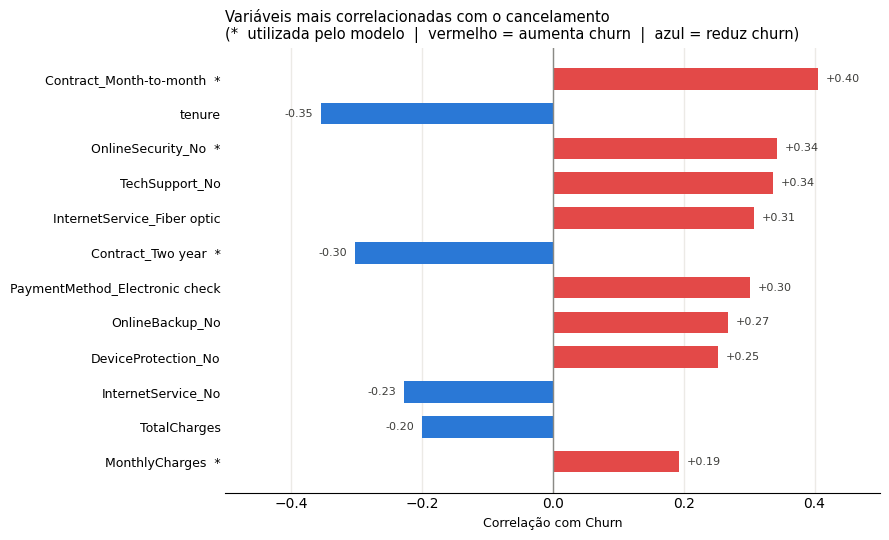

In [50]:
import matplotlib.pyplot as plt

# Preparação: todas as variáveis
df_corr = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(columns=['customerID'])

# TotalCharges vem como texto por causa dos 11 registros em branco
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')
df_corr = df_corr.dropna()

# Alvo em formato numérico
df_corr['Churn'] = (df_corr['Churn'] == 'Yes').astype(int)

# One-Hot Encoding: cada categoria vira uma coluna própria, sem criar ordem artificial
dummies = pd.get_dummies(df_corr, drop_first=False)

# Correlação de cada variável com o churn
correlacoes = dummies.corr(numeric_only=True)['Churn'].drop('Churn')

# Remove categorias redundantes ("No internet service" / "No phone service")
correlacoes = correlacoes[~correlacoes.index.str.contains('No internet service|No phone service')]

top = correlacoes.reindex(correlacoes.abs().sort_values(ascending=False).index).head(12)
print(top.round(3))

# Gráfico
usadas = ['Contract_Month-to-month', 'Contract_Two year', 'Contract_One year',
          'OnlineSecurity_No', 'OnlineSecurity_Yes', 'MonthlyCharges']

top = top[::-1]
cores = ['#e34948' if v > 0 else '#2a78d6' for v in top.values]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(range(len(top)), top.values, color=cores, height=0.62)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([f"{n}  *" if n in usadas else n for n in top.index], fontsize=9)
ax.axvline(0, color='#8a8a85', linewidth=1)

for i, v in enumerate(top.values):
    ax.text(v + (0.012 if v > 0 else -0.012), i, f"{v:+.2f}", va='center',
            ha='left' if v > 0 else 'right', fontsize=8, color='#3d3d3a')

ax.set_xlim(-0.5, 0.5)
ax.set_xlabel('Correlação com Churn', fontsize=9)
ax.set_title('Variáveis mais correlacionadas com o cancelamento\n'
             '(*  utilizada pelo modelo  |  vermelho = aumenta churn  |  azul = reduz churn)',
             fontsize=10.5, loc='left')

for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)
ax.tick_params(length=0)
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='#eceae6', linewidth=1)
plt.tight_layout()
plt.show()

### Interpretação do Dataset

Analisando os dados, a característica mais relevante para o treinamento é o **desbalanceamento das classes**: apenas 26,54% dos registros correspondem a churn. Isso significa que um modelo que simplesmente respondesse sempre "não cancela" já alcançaria cerca de 73% de acurácia sem aprender nada. Por esse motivo, a acurácia isolada não é uma métrica confiável neste problema, e a avaliação precisa observar principalmente o recall da classe de churn.

Quanto à preparação dos dados, duas questões se destacam. Primeiro, as variáveis categóricas precisam ser convertidas em números, pois o Perceptron opera apenas com operações matemáticas. Segundo, as escalas são muito diferentes — `MonthlyCharges` chega a 118,75 enquanto as variáveis codificadas ficam entre 0 e 2 — o que torna a normalização indispensável para que a mensalidade não domine a soma ponderada apenas por ter números maiores.

Há ainda uma inconsistência a registrar: a coluna `TotalCharges` não apresenta valores nulos segundo o `isnull()`, mas contém 11 registros preenchidos com espaço em branco. São valores ausentes disfarçados de texto, que fazem a coluna ser lida como categórica. Como ela não é utilizada pelo modelo, isso não afeta este experimento, mas exigiria tratamento caso fosse incluída.

### Justificativa da seleção de variáveis

As três entradas utilizadas pelo modelo (`Contract`, `OnlineSecurity` e `MonthlyCharges`) foram herdadas do exemplo apresentado em aula. A análise de correlação foi realizada justamente para verificar se essa escolha se sustenta diante dos dados, utilizando One-Hot Encoding para evitar a ordem artificial que o LabelEncoder introduziria. O resultado é parcialmente favorável.

**Duas escolhas se confirmam:**

- **Contract** é a variável mais correlacionada de todo o dataset (+0.405 para contrato mensal e -0.302 para contrato de dois anos). A ausência de fidelização é o principal fator de risco.
- **OnlineSecurity** ocupa a terceira posição (+0.342) e funciona como indicador de vínculo: 41,8% dos clientes sem o serviço cancelaram, contra 14,6% dos que o contrataram.

**Uma escolha se mostra frágil:**

- **MonthlyCharges** aparece apenas na décima segunda posição (+0.193). A diferença entre as classes existe. Quem cancelou pagava em média R$ 74,44, contra R$ 61,27 de quem permaneceu.

Mais importante, variáveis de alto poder preditivo ficaram de fora do modelo: `tenure` (tempo de permanência) é a segunda mais correlacionada de todo o dataset (-0.354), e `TechSupport_No` (+0.337), `InternetService_Fiber optic` (+0.307) e `PaymentMethod_Electronic check` (+0.301) também superam `MonthlyCharges`. Como o modelo utiliza apenas 3 dos 20 atributos disponíveis, grande parte da informação útil não chega ao Perceptron, o que ajuda a explicar, desde já, a dificuldade esperada em identificar corretamente os clientes propensos ao cancelamento.

In [51]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Carregar os dados
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')


# Selecionar as colunas relevantes
features = ['MonthlyCharges', 'Contract', 'OnlineSecurity', 'Churn']
df = df[features]


# Tratar valores faltantes
df = df.dropna()


# Codificação de variáveis categóricas
label_encoders = {}

for col in ['Contract', 'OnlineSecurity', 'Churn']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


# Separar variáveis independentes e dependente
X = df[['MonthlyCharges', 'Contract', 'OnlineSecurity']].values
y = df['Churn'].values


# Normalizar os dados
scaler = StandardScaler()
X = scaler.fit_transform(X)


# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)


# Implementação do Perceptron
class Perceptron:

    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def activation(self, x):
        return 1 if x >= 0 else 0

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):

            for idx, x_i in enumerate(X):

                linear_output = np.dot(x_i, self.weights) + self.bias

                y_pred = self.activation(linear_output)

                # Atualização dos pesos
                update = self.lr * (y[idx] - y_pred)

                self.weights += update * x_i
                self.bias += update

    def predict(self, X):

        linear_output = np.dot(X, self.weights) + self.bias

        return np.array(
            [self.activation(x) for x in linear_output]
        )


# Treinar o modelo
perceptron = Perceptron(lr=0.01, epochs=1000)

perceptron.fit(X_train, y_train)


# Realizar previsões
y_pred = perceptron.predict(X_test)


# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)

conf_matrix = confusion_matrix(y_test, y_pred)

report = classification_report(y_test, y_pred)


# Exibir os resultados
print(f"Acurácia: {accuracy:.4f}")

print("Matriz de Confusão:\n", conf_matrix)

print("Relatório de Classificação:\n", report)

Acurácia: 0.7132
Matriz de Confusão:
 [[1342  197]
 [ 409  165]]
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.77      0.87      0.82      1539
           1       0.46      0.29      0.35       574

    accuracy                           0.71      2113
   macro avg       0.61      0.58      0.58      2113
weighted avg       0.68      0.71      0.69      2113



## Análise do Exemplo 3

### 1. O que significa Churn dentro do problema estudado e quais são as classes que o Perceptron deverá distinguir?

Churn significa o **cancelamento do serviço pelo cliente**, ou seja, a evasão de
clientes da operadora. No dataset, essa informação está na coluna `Churn`, que
originalmente contém os valores "Yes" e "No".

Como o Perceptron trabalha apenas com números, o `LabelEncoder` converte esses
valores em:

- **classe 0** → "No" — o cliente permaneceu na operadora;
- **classe 1** → "Yes" — o cliente cancelou o serviço.

Trata-se, portanto, de um problema de **classificação binária**: o Perceptron
recebe as características do cliente e deve decidir a qual dessas duas classes ele
pertence.

Na prática, a classe de maior interesse para a empresa é a classe 1, pois
identificar antecipadamente quem tende a cancelar permite agir antes da perda do
cliente.

### 2. Por que algumas variáveis do dataset precisam ser transformadas antes de serem fornecidas ao Perceptron? Identifique e explique pelo menos uma transformação realizada.

O Perceptron realiza operações matemáticas — multiplica cada entrada pelo seu peso
e soma os resultados. Por isso ele só aceita **valores numéricos** e é sensível à
**escala** desses valores. Variáveis em texto não podem ser multiplicadas, e
variáveis em escalas muito diferentes desequilibram a soma ponderada.

**Transformação 1 — Codificação das variáveis categóricas (LabelEncoder):**

As colunas `Contract`, `OnlineSecurity` e `Churn` contêm texto e foram convertidas em números.

**Transformação 2 — Normalização (StandardScaler):**

`MonthlyCharges` varia aproximadamente de 18 a 119, enquanto as colunas
codificadas variam de 0 a 2. Se os dados fossem usados nessa escala, a mensalidade
dominaria a soma ponderada apenas por ter números maiores, e não por ser mais
relevante. O `StandardScaler` coloca todas as variáveis na mesma escala (média 0 e
desvio padrão 1), permitindo que os pesos reflitam a importância real de cada
atributo.

**Observação crítica:** o `LabelEncoder` cria uma ordem numérica que não existe nos
dados originais. Em `OnlineSecurity`, por exemplo, os valores "No", "No internet
service" e "Yes" tornam-se 0, 1 e 2, sugerindo ao modelo uma progressão que é
artificial. Para variáveis sem ordem natural, o ideal seria usar One-Hot Encoding.

### 3. Por que o StandardScaler deve aprender seus parâmetros (fit) utilizando somente o conjunto de treinamento e não todo o dataset? Qual problema poderia ocorrer se utilizássemos informações do conjunto de teste nessa etapa?

O `StandardScaler` calcula a média e o desvio padrão dos dados durante o `fit` e
usa esses valores para padronizar as variáveis. Se o `fit` for feito sobre o
dataset completo, essas estatísticas incluem os dados de teste, ou seja,
informações que o modelo não deveria conhecer antes da avaliação.

Esse problema é chamado de **data leakage** (vazamento de dados). O conjunto de
teste existe para simular dados novos, nunca vistos. Se ele participa do cálculo
da normalização, deixa de ser realmente desconhecido, e o desempenho medido fica
otimista demais, melhor do que o modelo alcançaria em produção, diante de
clientes de fato novos.

O procedimento correto é:
- `fit_transform(X_train)` → aprende média e desvio apenas do treino e transforma
  o treino;
- `transform(X_test)` → aplica ao teste os parâmetros já aprendidos, sem recalcular.

**Observação sobre o código deste exemplo:** aqui a normalização foi aplicada com
`fit_transform(X)` **antes** da divisão treino/teste, ou seja, o escalonamento usou
informações de todo o dataset. A célula seguinte reproduz o experimento na ordem
correta para verificar o efeito dessa diferença.

In [52]:
# Normalização na ordem correta: divide primeiro, normaliza depois

# Dados sem normalização (X_sem_escala) e alvo
X_sem_escala = df[['MonthlyCharges', 'Contract', 'OnlineSecurity']].values
y = df['Churn'].values

# 1) Divisão entre treino e teste ANTES de normalizar
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_sem_escala,
    y,
    test_size=0.3,
    random_state=42
)

# 2) O scaler aprende (fit) SOMENTE com o treino
scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)

# 3) O teste é apenas transformado, com os parâmetros aprendidos no treino
X_test_c = scaler_c.transform(X_test_c)

# Treinamento com a mesma configuração original
perceptron_c = Perceptron(lr=0.01, epochs=1000)
perceptron_c.fit(X_train_c, y_train_c)

y_pred_c = perceptron_c.predict(X_test_c)

print("Normalização aplicada após a divisão treino/teste")
print(f"Acurácia: {accuracy_score(y_test_c, y_pred_c):.4f}")
print("Matriz de Confusão:\n", confusion_matrix(y_test_c, y_pred_c))
print("Relatório de Classificação:\n", classification_report(y_test_c, y_pred_c))

Normalização aplicada após a divisão treino/teste
Acurácia: 0.7317
Matriz de Confusão:
 [[1128  411]
 [ 156  418]]
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.88      0.73      0.80      1539
           1       0.50      0.73      0.60       574

    accuracy                           0.73      2113
   macro avg       0.69      0.73      0.70      2113
weighted avg       0.78      0.73      0.74      2113



**Comparação entre as duas ordens de execução:**

| Métrica | Normalização antes da divisão (código original) | Normalização após a divisão |
|---|---|---|
| Acurácia | 0.7132 | 0.7317 |
| Recall da classe 1 (churn) | 0.29 | 0.73 |
| F1-score da classe 1 | 0.35 | 0.60 |
| Falsos negativos | 409 | 156 |

Aplicar a normalização na ordem correta alterou de forma relevante o resultado.
O modelo passou a identificar 418 dos 574 clientes que cancelaram, contra apenas
165 na versão original — uma queda de 409 para 156 falsos negativos.

É importante ressaltar que a diferença não vem de o modelo ter "melhorado por
corrigir o vazamento": ela vem do fato de que os parâmetros de escala passaram a
ser outros, o que alterou o caminho da convergência do Perceptron. O ganho
observado é, portanto, um efeito colateral. O que justifica a mudança é a
correção metodológica: normalizar depois da divisão garante que o conjunto de
teste permaneça realmente desconhecido, e que as métricas medidas representem o
desempenho esperado diante de clientes novos.

### 4. Analise conjuntamente acurácia, precision, recall, F1-score e matriz de confusão. O modelo consegue identificar adequadamente os clientes que apresentam Churn?

Resultados obtidos na execução original do modelo (lr = 0.01, epochs = 1000): acurácia de 0.7132

Matriz de confusão:

| | Previsto 0 | Previsto 1 |
|---|---|---|
| **Real 0** | 1342 | 197 |
| **Real 1** | 409 | 165 |

| Classe | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| 0 (não cancelou) | 0.77 | 0.87 | 0.82 | 1539 |
| 1 (cancelou) | 0.46 | 0.29 | 0.35 | 574 |

**Resposta: não, o modelo não identifica adequadamente os clientes com churn.**

A acurácia de 71,32% parece razoável, mas é enganosa. Das 574 ocorrências reais de churn, o modelo detectou apenas 165 e deixou passar 409, os falsos negativos da matriz de confusão. Isso é exatamente o que o recall de 0.29 indica: o modelo encontra menos de um terço dos clientes que realmente cancelaram.

O precision de 0.46 mostra que, mesmo quando ele aponta churn, erra mais do que acerta: das 362 previsões de classe 1 (197 + 165), apenas 165 estavam corretas. O F1-score de 0.35, que combina as duas métricas, confirma o desempenho ruim nessa classe.

O contraste com a classe 0 (F1 de 0.82) revela a causa: o dataset é desbalanceado — 1539 clientes contra 574 no conjunto de teste. O modelo aprendeu a favorecer a classe majoritária, porque prever "não cancela" acerta na maior parte dos casos e mantém a acurácia alta.

Um teste simples comprova isso: um modelo que respondesse sempre 0, sem aprender nada, acertaria 1539 de 2113 casos, ou seja, 72,84% de acurácia, desempenho superior ao do Perceptron treinado. Portanto a acurácia não deve ser usada isoladamente neste problema.

**Implicação prática:** para a operadora, o erro custoso é o falso negativo, o cliente que ia cancelar e não foi identificado, perdendo-se a chance de retenção. Com 409 casos desse tipo, o modelo não atende ao objetivo do negócio. As três variáveis utilizadas e a fronteira de decisão linear do Perceptron não são suficientes para separar as classes.

### 5. Modifique a learning_rate ou o número de n_epochs, execute novamente o treinamento e compare os resultados com os valores originais. A alteração melhorou ou piorou o modelo? Justifique utilizando as métricas obtidas.

In [53]:
# Modificação: n_epochs reduzido de 1000 para 50 (learning_rate mantida em 0.01)
perceptron_mod = Perceptron(lr=0.01, epochs=50)

perceptron_mod.fit(X_train, y_train)

y_pred_mod = perceptron_mod.predict(X_test)

accuracy_mod = accuracy_score(y_test, y_pred_mod)
conf_matrix_mod = confusion_matrix(y_test, y_pred_mod)
report_mod = classification_report(y_test, y_pred_mod)

print("EXECUÇÃO MODIFICADA - lr = 0.01 | epochs = 50")
print(f"Acurácia: {accuracy_mod:.4f}")
print("Matriz de Confusão:\n", conf_matrix_mod)
print("Relatório de Classificação:\n", report_mod)

EXECUÇÃO MODIFICADA - lr = 0.01 | epochs = 50
Acurácia: 0.7345
Matriz de Confusão:
 [[1134  405]
 [ 156  418]]
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.88      0.74      0.80      1539
           1       0.51      0.73      0.60       574

    accuracy                           0.73      2113
   macro avg       0.69      0.73      0.70      2113
weighted avg       0.78      0.73      0.75      2113



**Modificação realizada:** número de épocas reduzido de 1000 para 50, mantendo a taxa de aprendizagem em 0.01.

| Métrica | Original (1000 épocas) | Modificado (50 épocas) |
|---|---|---|
| Acurácia | 0.7132 | 0.7345 |
| Precision (classe 1) | 0.46 | 0.51 |
| Recall (classe 1) | 0.29 | 0.73 |
| F1-score (classe 1) | 0.35 | 0.60 |
| Falsos negativos | 409 | 156 |
| Falsos positivos | 197 | 405 |

**A alteração melhorou o modelo.** Com menos épocas, o recall da classe de churn subiu de 0.29 para 0.73 e o F1-score quase dobrou, de 0.35 para 0.60. Os falsos negativos caíram de 409 para 156, ou seja, o modelo deixou de ignorar a maior parte dos clientes que realmente cancelaram, o que é justamente o objetivo do problema.

O custo foi o aumento dos falsos positivos, de 197 para 405: o modelo passou a sinalizar clientes que não cancelariam. Nesse contexto de negócio, porém, é um custo aceitável, pois abordar um cliente estável é menos prejudicial do que perder um cliente que iria cancelar.

**Por que menos épocas produziram um resultado melhor:** o dataset não é linearmente separável, então o Perceptron nunca converge, ele continua ajustando os pesos indefinidamente, oscilando entre diferentes fronteiras de decisão. O resultado final depende de em que ponto dessa oscilação o treinamento é interrompido. Executando o mesmo modelo com diferentes números de épocas, a acurácia variou entre 0.6895 e 0.7345 sem tendência de melhora contínua, confirmando o comportamento oscilatório. Portanto, treinar por mais tempo não significa aprender melhor.